# Exercise 2 - Micro 110

Note: empty markdown cells are for your responses. 

Note: a # symbol within the code indicates useful information for the code.

Note: You are expected to enter information anywhere with a ###### symbol.

For this question, you are going to perform some analyses on the data from the "donut eating professor" problem introduced in class. 

Reference the course's Jupyter exercise to help you navigate the code

In [6]:
# The following are import functions.  You do not need to change them
import numpy as np
from scipy import stats
import scipy
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import mean, median, variance
warnings.simplefilter('ignore', DeprecationWarning)

There are 12 professors at a hypothetical university.   Their weights are as follows:

| Professor | Weight (kg) | 
|:--------:|:--------:|
|  Schmuggles   |  75   | 
|  Bopsey   |  97   |  
|  Pallitto   |  86   |
| Homer | 85 |
| Schnickerson | 75 |
| Levin | 67 |
| Honkey-Doorey | 114 |
| Zingers | 140 |
| Boehmer | 69 |
| Queenie | 60 |
| Googles-Boop | 90 |
| Calzone | 103 |

(a) Generate a box plot for the above data set

Data: 
     Service Times
0              75
1              97
2              86
3              85
4              75
5              67
6             114
7             140
8              69
9              60
10             90
11            103


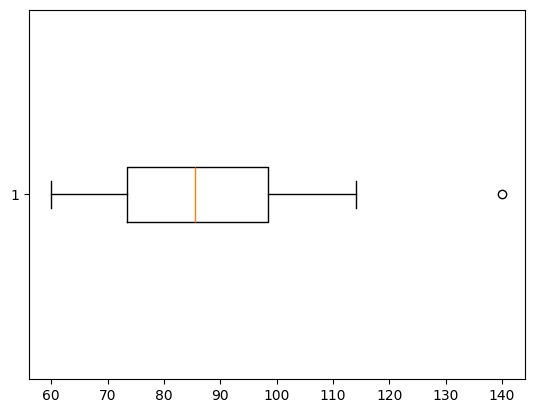

In [7]:
# The following code defines two arrays.  The first array lists the names of the professors.  The second array lists their weights, and is incomplete.   
# Complete the code for the second array.  Also add in the relevant code to print the mean, median, and mode
#####  Part a code below
data = np.array([75,97,86,85,75,67,114,140,69,60,90,103])
data = data.reshape(len(data), 1) # Prepare the data for pandas
df = pd.DataFrame(data=data, columns=['Service Times']) # Transform data to pandas DataFrame
print('Data: \n', df)
plt.boxplot(df, vert=False)
plt.show()





#####

(b) Determine the quantiles and the interquantile range.  Also, generate a list of outliers, assuming that outliers are defined as exceeding 1.5 times the IQR.

In [10]:
######## part b code below
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(f'Quantile 1 {Q1.values[0]}, Quantile 3 {Q3.values[0]}, IQR {IQR.values[0]}')

mask = ((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR)))
filtered_data = (mask*df).to_numpy()
print("Outliers:")
for datum in filtered_data:
    if(datum != 0):
        print(datum)



#######

Quantile 1 73.5, Quantile 3 98.5, IQR 25.0
Outliers:
[140]


(c) You should observe that there is one outlier in the above dataset.   One option is to just reject the outliers.   To do this, since we know that there is one outlier (which happens to be a high value), we will copy the array to a new array called weights_sorted, sort it, and copy N-1 elements of the array to another array called weights_sorted_removeoutliers. What are the mean, median, and mode when the outlier is removed?

In [13]:
#### code for part c
# You can copy an array to a new array by simply using array2 = array1
# You can sort an array using np.sort(array, axis=0)
# You can truncate the array by using array2 = array[1:len(array1)-1]

weights_sorted = np.array([75,97,86,85,75,67,114,69,60,90,103])
weights_sorted = weights_sorted.reshape(len(weights_sorted), 1) # Prepare the data for pandas
dfs = pd.DataFrame(data=weights_sorted, columns=['Service Times']) # Transform data to pandas DataFrame
print('Data: \n', dfs)
print("Sample mean sorted: ", mean(dfs))
print("Sample median sorted: ", median(dfs))
print("Sample mode sorted: ", stats.mode(dfs))


#####

Data: 
     Service Times
0              75
1              97
2              86
3              85
4              75
5              67
6             114
7              69
8              60
9              90
10            103
Sample mean sorted:  83.72727272727273
Sample median sorted:  85.0
Sample mode sorted:  ModeResult(mode=array([75]), count=array([2]))


If you did this correctly, you should have noticed that the mean changed quite a bit, but the median and mode didn't change.

(d) another way to deal with outliers is to reject high/low values.   Using the trimmed mean function, reject one high and one low value by choosing the appropriate r value

In [18]:
r = 0.499 # r value for trimming
print("Sample trimmed mean: ", stats.trim_mean(df, r))

Sample trimmed mean:  [85.5]
